In [7]:
import utils as u

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Obtain Data: all bands

In [3]:
data = u.extract_data()

display(data)


features_and_label = ['Teff', 'logg', 'bpDered','rpDered','gDered', 'e_bv', 'NUVDered','FeH']
selected_data = data[features_and_label].copy()
target_col   = 'FeH'
feature_cols = [c for c in selected_data.columns if c != target_col]
#remove all rows where logg is Nan
selected_data = selected_data.dropna(subset=['e_bv'])

print(f"Total rows after dropping NaNs: {len(selected_data)}")
print(f"FeH range: [{selected_data[target_col].min():.3f}, {selected_data[target_col].max():.3f}]")



mask_nuv = selected_data['NUVDered'] >= -700
removed_outliers = (~mask_nuv).sum()
selected_data = selected_data.loc[mask_nuv].copy()
print(f"Removed {removed_outliers} rows with NUVDered < -700; remaining {len(selected_data)} rows")
print("Columns used as features:")
print(selected_data.drop(columns=[target_col]).columns.tolist())


,Survey,FeH,NUVDered,bpDered,rpDered,gDered,bp_rp_dered,e_bv,Teff,logg,colorColorY
0,Bonifacio,-2.83,20.194627,14.954472,13.951378,14.540798,1.003094,0.060031,6303.000000,4.2500,-1.016775
1,Cayrel,-2.09,13.763638,9.322605,8.444117,8.977594,0.878489,0.059608,5250.000000,2.0000,-1.077013
2,Cayrel,-3.06,13.687658,8.866393,7.847339,8.451915,1.019055,0.193103,19883.960940,3.8566,-1.862718
3,Cayrel,-3.71,17.854393,14.191398,13.307462,13.841487,0.883936,0.017698,5250.000000,3.0000,-1.778273
4,Cayrel,-3.35,19.073609,14.298530,13.276527,13.877312,1.022003,0.027137,5456.290527,2.7236,-1.514804
...,...,...,...,...,...,...,...,...,...,...,...
588,Yong,-2.60,18.570030,16.229182,15.647004,16.009031,0.582178,0.027532,6507.000000,4.2900,-1.297989
589,Yong,-2.65,17.412597,14.902701,14.332306,14.695168,0.570395,0.018709,6624.000000,4.1100,-1.041163
590,Yong,-2.60,18.019629,15.639227,15.059055,15.426493,0.580172,0.027431,6479.000000,4.3100,-1.252573
591,Yong,-2.68,18.129256,15.619711,14.955302,15.369438,0.664409,0.017284,6196.000000,3.7700,-1.605187


Total rows after dropping NaNs: 593
FeH range: [-5.760, -0.630]
Removed 6 rows with NUVDered < -700; remaining 587 rows
Columns used as features:
['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']


# obtain data: color

In [2]:
data = u.extract_data()
display(data)

features_and_label = [
    'Teff', 'logg', 'bp_rp_dered','colorColorY','NUVDered',
    'e_bv', 'FeH'
]

selected_data = data[features_and_label].copy()
target_col   = 'FeH'
feature_cols = [c for c in selected_data.columns if c != target_col]

# Remove rows where e_bv is NaN
selected_data = selected_data.dropna(subset=['e_bv'])

print(f"Total rows after dropping NaNs: {len(selected_data)}")

# Apply NUVDered quality cut
mask_nuv = selected_data['NUVDered'] >= -700
removed_outliers = (~mask_nuv).sum()
selected_data = selected_data.loc[mask_nuv].copy()

print(f"Removed {removed_outliers} rows with NUVDered < -700; remaining {len(selected_data)} rows")

selected_data = selected_data.drop(columns=['NUVDered'])

# Update feature list after drop
feature_cols = [c for c in selected_data.columns if c != target_col]

print("\nFinal feature columns used:")
print(feature_cols)

print(f"FeH range: [{selected_data[target_col].min():.3f}, {selected_data[target_col].max():.3f}]")


,Survey,FeH,NUVDered,bpDered,rpDered,gDered,bp_rp_dered,e_bv,Teff,logg,colorColorY
0,Bonifacio,-2.83,20.194627,14.954472,13.951378,14.540798,1.003094,0.060031,6303.000000,4.2500,-1.016775
1,Cayrel,-2.09,13.763638,9.322605,8.444117,8.977594,0.878489,0.059608,5250.000000,2.0000,-1.077013
2,Cayrel,-3.06,13.687658,8.866393,7.847339,8.451915,1.019055,0.193103,19883.960940,3.8566,-1.862718
3,Cayrel,-3.71,17.854393,14.191398,13.307462,13.841487,0.883936,0.017698,5250.000000,3.0000,-1.778273
4,Cayrel,-3.35,19.073609,14.298530,13.276527,13.877312,1.022003,0.027137,5456.290527,2.7236,-1.514804
...,...,...,...,...,...,...,...,...,...,...,...
588,Yong,-2.60,18.570030,16.229182,15.647004,16.009031,0.582178,0.027532,6507.000000,4.2900,-1.297989
589,Yong,-2.65,17.412597,14.902701,14.332306,14.695168,0.570395,0.018709,6624.000000,4.1100,-1.041163
590,Yong,-2.60,18.019629,15.639227,15.059055,15.426493,0.580172,0.027431,6479.000000,4.3100,-1.252573
591,Yong,-2.68,18.129256,15.619711,14.955302,15.369438,0.664409,0.017284,6196.000000,3.7700,-1.605187


Total rows after dropping NaNs: 593
Removed 6 rows with NUVDered < -700; remaining 587 rows

Final feature columns used:
['Teff', 'logg', 'bp_rp_dered', 'colorColorY', 'e_bv']
FeH range: [-5.760, -0.630]


# Scale and Split (no smote)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from imblearn.over_sampling import SMOTE
# from imblearn.combine import SMOTEENN
# from imblearn.under_sampling import EditedNearestNeighbours



def scale_and_split(data, target_column, test_size=0.2, random_state=42, use_smote = False, scale= True):
    """
    Splits the dataset into training and validation sets, and scales the features.

    Parameters:
    - data: pd.DataFrame
    - target_column: str, name of the target column
    - test_size: float, proportion of validation set
    - random_state: int, for reproducibility

    Returns:
    - X_train_scaled, X_val_scaled, y_train, y_val, scaler
    """
    # Separate features and target
    X = data.drop(columns=[target_column]).copy()
    y = data[target_column].copy()

    # Split into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    #Resample with smote if True
    if use_smote:
        smote = SMOTEENN(
            sampling_strategy={0:500,1: 400},
            random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    if scale:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        return X_train_scaled, X_val_scaled, y_train.values, y_val.values, scaler
    else:
        return X_train.values, X_val.values, y_train.values, y_val.values, None
print(target_col)
x_train, x_val, y_train, y_val,scaler= scale_and_split(selected_data, target_col, use_smote=False)




FeH


# Simple Linear Regression

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def FeH_regression_model(X_train, y_train, X_valid, y_valid):
    """
    Multiple linear regression model to predict FeH (metallicity)
    from stellar/photometric features.
    """

    model = LinearRegression()
    model.fit(X_train, y_train)


    y_pred = model.predict(X_valid)

    mse  = mean_squared_error(y_valid, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_valid, y_pred)

    print(f"Validation RMSE: {rmse:.4f}")
    print(f"Validation R^2:  {r2:.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(y_valid, y_pred, alpha=0.6)
    min_val = min(y_valid.min(), y_pred.min())
    max_val = max(y_valid.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.xlabel("True FeH")
    plt.ylabel("Predicted FeH")
    plt.title("True vs Predicted FeH (Validation)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    residuals = y_valid - y_pred

    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, bins=30, kde=True)
    plt.xlabel("Residual (FeH_true - FeH_pred)")
    plt.ylabel("Count")
    plt.title("Residual Distribution (Validation)")
    plt.tight_layout()
    plt.show()

    return model


Validation RMSE: 0.4697
Validation R^2:  0.1054


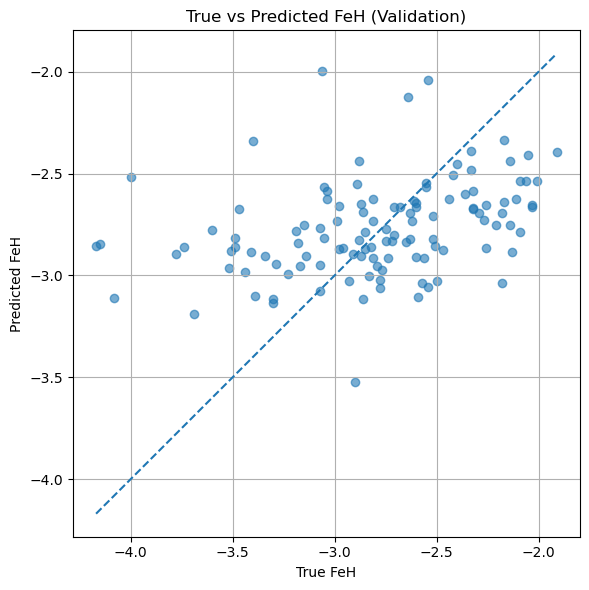

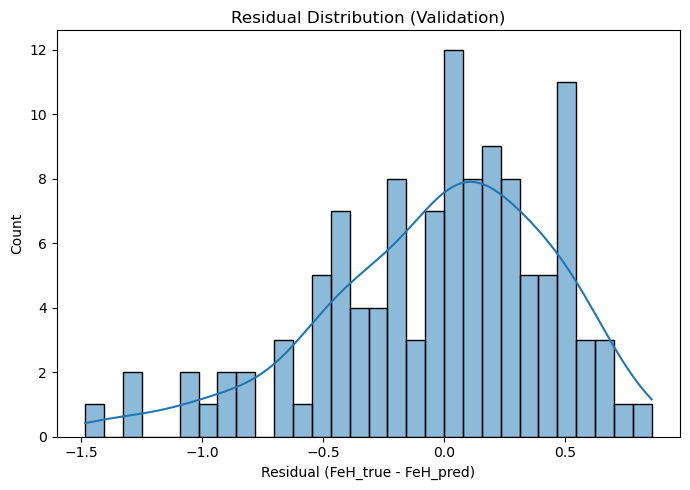

In [5]:
feh_model = FeH_regression_model(x_train, y_train, x_val, y_val)

 # Ridge L2 regression

Features used in regression model:
['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']

Best alpha (L2 strength): 11.49757

Alpha vs CV RMSE (training folds):
  alpha =    0.001   CV_RMSE = 0.5229
  alpha =  0.00115   CV_RMSE = 0.5229
  alpha = 0.001322   CV_RMSE = 0.5229
  alpha =  0.00152   CV_RMSE = 0.5229
  alpha = 0.001748   CV_RMSE = 0.5229
  alpha = 0.002009   CV_RMSE = 0.5229
  alpha =  0.00231   CV_RMSE = 0.5228
  alpha = 0.002656   CV_RMSE = 0.5228
  alpha = 0.003054   CV_RMSE = 0.5228
  alpha = 0.003511   CV_RMSE = 0.5228
  alpha = 0.004037   CV_RMSE = 0.5228
  alpha = 0.004642   CV_RMSE = 0.5227
  alpha = 0.005337   CV_RMSE = 0.5227
  alpha = 0.006136   CV_RMSE = 0.5227
  alpha = 0.007055   CV_RMSE = 0.5227
  alpha = 0.008111   CV_RMSE = 0.5226
  alpha = 0.009326   CV_RMSE = 0.5226
  alpha =  0.01072   CV_RMSE = 0.5225
  alpha =  0.01233   CV_RMSE = 0.5225
  alpha =  0.01417   CV_RMSE = 0.5224
  alpha =   0.0163   CV_RMSE = 0.5224
  alpha =  0.01874   CV_RM

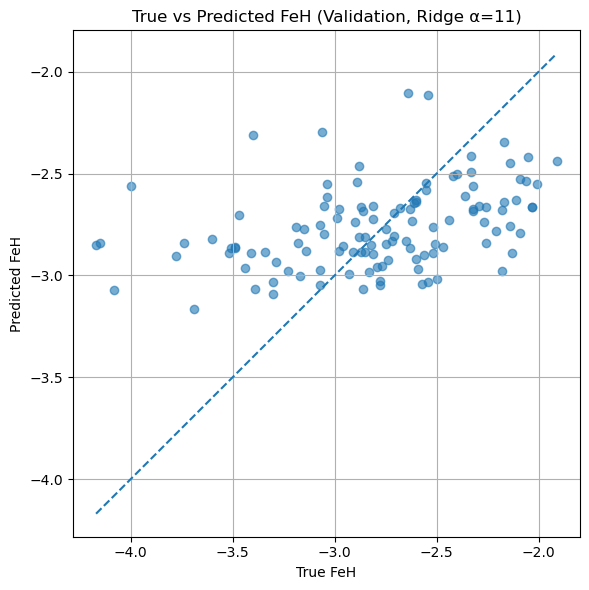

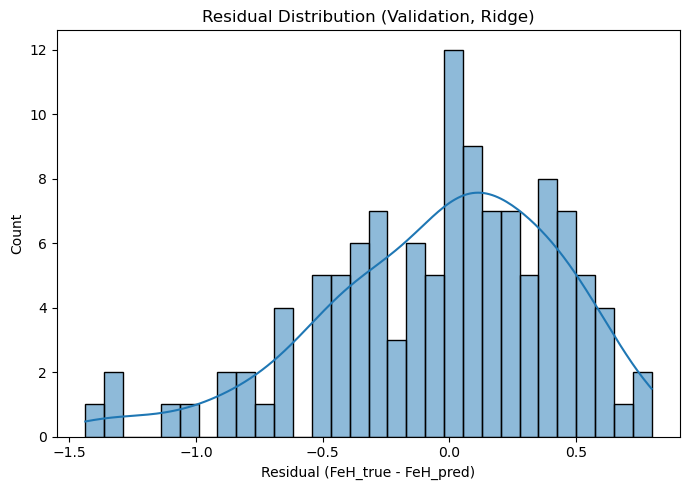

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


def FeH_regression_model(X_train, y_train, X_valid, y_valid,
                         feature_names=None,
                         alphas=None,
                         cv_folds=5):
    """
    Ridge (L2) regression model to predict FeH (metallicity)
    from stellar/photometric features.

    - Tunes alpha (L2 strength) with cross-validation on the *training* set.
    - Evaluates the best model on the validation set.
    - Plots True vs Predicted FeH and residuals.
    """

    if feature_names is not None:
        print("Features used in regression model:")
        print(list(feature_names))

    if alphas is None:
        # Try 15 values from 1e-3 to 1e3 on a log scale
        alphas = np.logspace(-3, 3, 100)

    ridge = Ridge(max_iter=10000)

    param_grid = {'alpha': alphas}

    search = GridSearchCV(
        estimator=ridge,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',  # we will turn this into RMSE
        cv=cv_folds
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_alpha = search.best_params_['alpha']
    print(f"\nBest alpha (L2 strength): {best_alpha:.5f}")


    mean_neg_mse = search.cv_results_['mean_test_score']
    alpha_vals   = search.cv_results_['param_alpha'].data.astype(float)
    rmse_vals    = np.sqrt(-mean_neg_mse)

    print("\nAlpha vs CV RMSE (training folds):")
    for a, rm in zip(alpha_vals, rmse_vals):
        print(f"  alpha = {a:8.4g}   CV_RMSE = {rm:.4f}")


    y_pred = best_model.predict(X_valid)

    mse  = mean_squared_error(y_valid, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_valid, y_pred)

    print(f"\nValidation RMSE: {rmse:.4f}")
    print(f"Validation R^2:  {r2:.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(y_valid, y_pred, alpha=0.6)
    min_val = min(y_valid.min(), y_pred.min())
    max_val = max(y_valid.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.xlabel("True FeH")
    plt.ylabel("Predicted FeH")
    plt.title(f"True vs Predicted FeH (Validation, Ridge α={best_alpha:.2g})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    residuals = y_valid - y_pred

    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, bins=30, kde=True)
    plt.xlabel("Residual (FeH_true - FeH_pred)")
    plt.ylabel("Count")
    plt.title("Residual Distribution (Validation, Ridge)")
    plt.tight_layout()
    plt.show()

    return best_model, search
# Assume selected_data and target_col = 'FeH' are already defined
x_train, x_val, y_train, y_val, scaler = scale_and_split(selected_data, target_col)

feature_names = selected_data.drop(columns=[target_col]).columns
ridge_model, ridge_search = FeH_regression_model(
    x_train, y_train, x_val, y_val,
    feature_names=feature_names
)


# Elastic Net

Features used: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']


C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.957e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.869e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.958e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.871e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.960e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.873e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.961e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.876e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

...

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.895e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.029e+01, tolerance: 1.028e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.933e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.931e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.960e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.151e+01, tolerance: 1.238e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 

C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.978e+01, tolerance: 1.202e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\xswu0\anaconda3\envs\python38\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.972e+01, tolerance: 1.200e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers 


Best Hyperparameters:
  Alpha:     0.02915
  L1 Ratio:  0
Validation RMSE: 0.4609
Validation R²:  0.1384


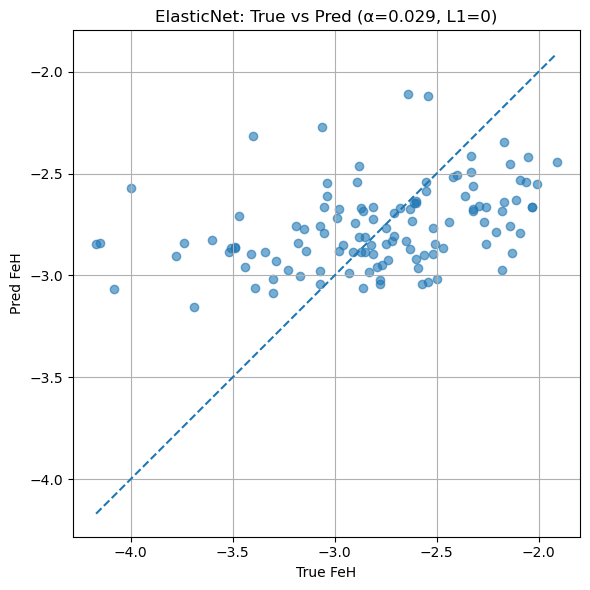

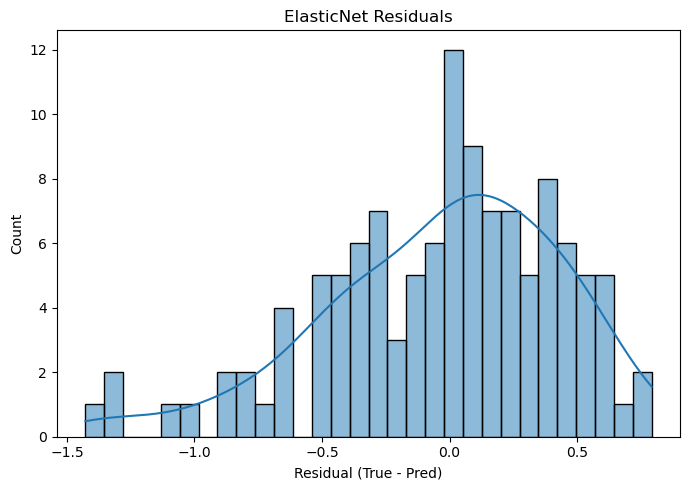

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


def FeH_regression_elasticnet(X_train, y_train, X_valid, y_valid,
                              feature_names=None,
                              alphas=None, l1_ratios=None,
                              cv_folds=5):
    
    if feature_names is not None:
        print("Features used:", list(feature_names))

    # Hyperparameter grids
    if alphas is None:
        alphas = np.logspace(-3, 2, 100)  # 1e-3 to 1e2
    if l1_ratios is None:
        l1_ratios = np.linspace(0.0, 1.0, 60)  # [L2 → L1]

    enet = ElasticNet(max_iter=10000)

    param_grid = {
        'alpha': alphas,
        'l1_ratio': l1_ratios
    }

    search = GridSearchCV(
        estimator=enet,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=cv_folds
    )

    search.fit(X_train, y_train)

    best_alpha = search.best_params_['alpha']
    best_l1 = search.best_params_['l1_ratio']
    best_model = search.best_estimator_

    print(f"\nBest Hyperparameters:")
    print(f"  Alpha:     {best_alpha:.4g}")
    print(f"  L1 Ratio:  {best_l1:.4g}")

    # Validation
    y_pred = best_model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    r2 = r2_score(y_valid, y_pred)

    print(f"Validation RMSE: {rmse:.4f}")
    print(f"Validation R²:  {r2:.4f}")

    # Plot: True vs Predicted
    plt.figure(figsize=(6,6))
    plt.scatter(y_valid, y_pred, alpha=0.6)
    min_v = min(y_valid.min(), y_pred.min())
    max_v = max(y_valid.max(), y_pred.max())
    plt.plot([min_v,max_v],[min_v,max_v],'--')
    plt.xlabel("True FeH")
    plt.ylabel("Pred FeH")
    plt.title(f"ElasticNet: True vs Pred (α={best_alpha:.2g}, L1={best_l1:.2g})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot residuals
    residuals = y_valid - y_pred
    plt.figure(figsize=(7,5))
    sns.histplot(residuals, bins=30, kde=True)
    plt.xlabel("Residual (True - Pred)")
    plt.title("ElasticNet Residuals")
    plt.tight_layout()
    plt.show()

    return best_model, search
feature_names = selected_data.drop(columns=[target_col]).columns
enet_model, enet_search = FeH_regression_elasticnet(
    x_train, y_train, x_val, y_val,
    feature_names=feature_names,
    cv_folds=5
)


# polynomial

Features used: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
Train size: 469, Val size: 118

Best Hyperparameters:
  degree: 1
  alpha:  11.27

Validation RMSE: 0.4604
Validation R²:  0.1403


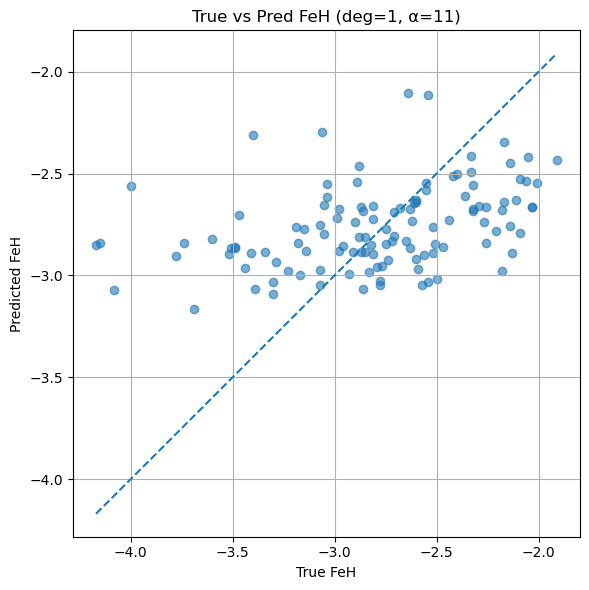

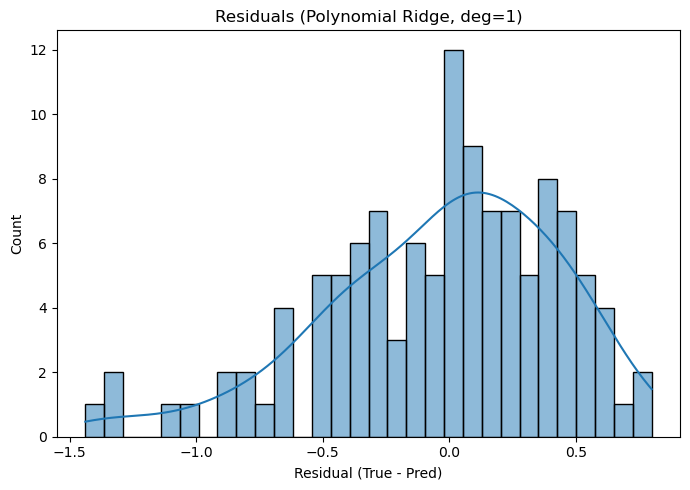


Grid search results (degree, alpha, CV_RMSE):
  deg=1, alpha=   0.001 -> CV_RMSE=0.5229
  deg=1, alpha=0.001028 -> CV_RMSE=0.5229
  deg=1, alpha=0.001057 -> CV_RMSE=0.5229
  deg=1, alpha=0.001087 -> CV_RMSE=0.5229
  deg=1, alpha=0.001117 -> CV_RMSE=0.5229
  deg=1, alpha=0.001148 -> CV_RMSE=0.5229
  deg=1, alpha=0.001181 -> CV_RMSE=0.5229
  deg=1, alpha=0.001214 -> CV_RMSE=0.5229
  deg=1, alpha=0.001248 -> CV_RMSE=0.5229
  deg=1, alpha=0.001283 -> CV_RMSE=0.5229
  deg=1, alpha=0.001319 -> CV_RMSE=0.5229
  deg=1, alpha=0.001356 -> CV_RMSE=0.5229
  deg=1, alpha=0.001394 -> CV_RMSE=0.5229
  deg=1, alpha=0.001433 -> CV_RMSE=0.5229
  deg=1, alpha=0.001473 -> CV_RMSE=0.5229
  deg=1, alpha=0.001515 -> CV_RMSE=0.5229
  deg=1, alpha=0.001557 -> CV_RMSE=0.5229
  deg=1, alpha=0.001601 -> CV_RMSE=0.5229
  deg=1, alpha=0.001646 -> CV_RMSE=0.5229
  deg=1, alpha=0.001692 -> CV_RMSE=0.5229
  deg=1, alpha= 0.00174 -> CV_RMSE=0.5229
  deg=1, alpha=0.001789 -> CV_RMSE=0.5229
  deg=1, alpha=0.001839 -> CV

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


def poly_ridge_experiment(df, feature_cols, target_col='FeH',
                          degrees=(1, 2),
                          alphas=None,
                          test_size=0.2,
                          random_state=42,
                          cv_folds=5):
    """
    Polynomial + Ridge regression experiment for FeH.

    - degrees: tuple of polynomial degrees to try (e.g., (1,2))
        * degree=1  -> plain linear model
        * degree=2  -> adds squares + cross-terms
    - alphas: list/array of Ridge regularization strengths; if None, uses logspace grid
    """

    if alphas is None:
        alphas = np.logspace(-3, 3, 500)   # 1e-3 to 1e3


    X = df[feature_cols].values
    y = df[target_col].values.astype(float)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print("Features used:", feature_cols)
    print(f"Train size: {len(y_train)}, Val size: {len(y_val)}")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly",   PolynomialFeatures(include_bias=False)),
        ("ridge",  Ridge(max_iter=10000))
    ])

    param_grid = {
        "poly__degree": degrees,
        "ridge__alpha": alphas
    }

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=cv_folds
    )


    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_deg   = search.best_params_["poly__degree"]
    best_alpha = search.best_params_["ridge__alpha"]

    print("\nBest Hyperparameters:")
    print(f"  degree: {best_deg}")
    print(f"  alpha:  {best_alpha:.4g}")


    y_pred = best_model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2   = r2_score(y_val, y_pred)

    print(f"\nValidation RMSE: {rmse:.4f}")
    print(f"Validation R²:  {r2:.4f}")


    plt.figure(figsize=(6, 6))
    plt.scatter(y_val, y_pred, alpha=0.6)
    min_v = min(y_val.min(), y_pred.min())
    max_v = max(y_val.max(), y_pred.max())
    plt.plot([min_v, max_v], [min_v, max_v], "--")
    plt.xlabel("True FeH")
    plt.ylabel("Predicted FeH")
    plt.title(f"True vs Pred FeH (deg={best_deg}, α={best_alpha:.2g})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    residuals = y_val - y_pred
    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, bins=30, kde=True)
    plt.xlabel("Residual (True - Pred)")
    plt.ylabel("Count")
    plt.title(f"Residuals (Polynomial Ridge, deg={best_deg})")
    plt.tight_layout()
    plt.show()


    mean_rmse = np.sqrt(-search.cv_results_["mean_test_score"])
    degrees_grid = search.cv_results_["param_poly__degree"].data.astype(int)
    alphas_grid  = search.cv_results_["param_ridge__alpha"].data.astype(float)

    print("\nGrid search results (degree, alpha, CV_RMSE):")
    for d, a, r in zip(degrees_grid, alphas_grid, mean_rmse):
        print(f"  deg={d}, alpha={a:8.4g} -> CV_RMSE={r:.4f}")

    return best_model, search




best_poly_ridge, poly_ridge_search = poly_ridge_experiment(
    selected_data,
    feature_cols=feature_cols,
    target_col=target_col,
    degrees=(1, 2),           # let it choose between linear and quadratic
    cv_folds=5
)


# partial polynomial preselected

Best degree on poly features: 1
Best alpha:                 19.31
Validation RMSE: 0.4621
Validation R²:  0.1339


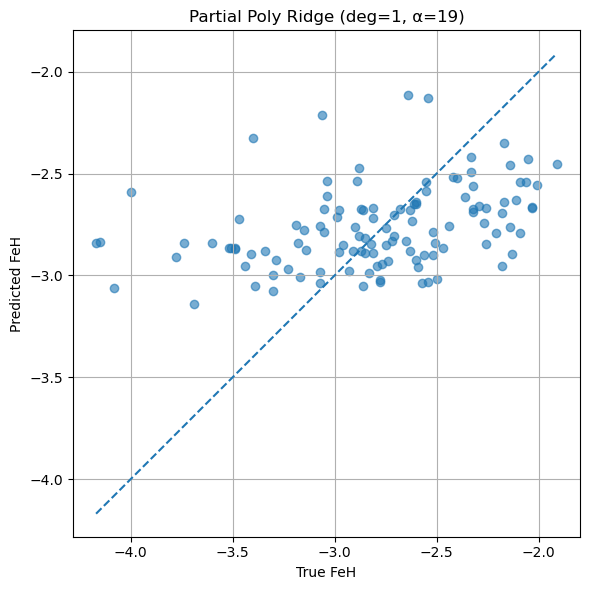

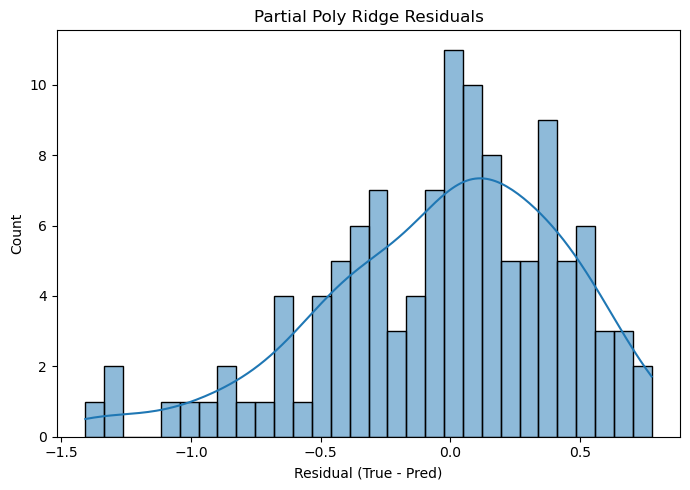

In [9]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

poly_cols   = ['Teff', 'bpDered','rpDered']        # nonlinear
linear_cols = ['logg', 'e_bv', 'gDered', 'NUVDered']  # keep linear

def partial_poly_ridge(df, target_col='FeH',
                       poly_degree_grid=(1, 2),
                       alphas=None,
                       test_size=0.2,
                       random_state=42,
                       cv_folds=5):

    if alphas is None:
        alphas = np.logspace(-3, 3, 8)

    X = df[poly_cols + linear_cols]
    y = df[target_col].astype(float).values

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Column-wise feature engineering
    col_trans = ColumnTransformer(
        transformers=[
            ("poly",   PolynomialFeatures(include_bias=False), poly_cols),
            ("linear", "passthrough",                         linear_cols),
        ]
    )

    pipe = Pipeline([
        ("features", col_trans),
        ("scaler",   StandardScaler()),
        ("ridge",    Ridge(max_iter=10000))
    ])

    param_grid = {
        "features__poly__degree": poly_degree_grid,
        "ridge__alpha": alphas
    }

    search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=cv_folds
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_deg   = search.best_params_["features__poly__degree"]
    best_alpha = search.best_params_["ridge__alpha"]

    print(f"Best degree on poly features: {best_deg}")
    print(f"Best alpha:                 {best_alpha:.4g}")

    y_pred = best_model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2   = r2_score(y_val, y_pred)
    print(f"Validation RMSE: {rmse:.4f}")
    print(f"Validation R²:  {r2:.4f}")

    # True vs Pred
    plt.figure(figsize=(6,6))
    plt.scatter(y_val, y_pred, alpha=0.6)
    miv, mav = min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())
    plt.plot([miv, mav], [miv, mav], '--')
    plt.xlabel("True FeH")
    plt.ylabel("Predicted FeH")
    plt.title(f"Partial Poly Ridge (deg={best_deg}, α={best_alpha:.2g})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Residuals
    residuals = y_val - y_pred
    plt.figure(figsize=(7,5))
    sns.histplot(residuals, bins=30, kde=True)
    plt.xlabel("Residual (True - Pred)")
    plt.title("Partial Poly Ridge Residuals")
    plt.tight_layout()
    plt.show()

    return best_model, search

best_pp_model, pp_search = partial_poly_ridge(selected_data, target_col)



# Partial Polynomial loop over combinations

Feature columns: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
Train size: 469,  Val size: 118

Trying poly features: NONE
Linear-only features: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff']
Linear-only features: ['logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
  -> Best degree: 2
  -> Best alpha:  10.99
  -> Val RMSE:    0.4694
  -> Val R²:      0.1066

Trying poly features: ['logg']
Linear-only features: ['Teff', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
  -> Best degree: 2
  -> Best alpha:  3.556
  -> Val RMSE:    0.4600
  -> Val R²:      0.1419

Trying poly features: ['bpDered']
Linear-only features: ['Teff', 'logg', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['rpDered']
Linear-

  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'e_bv']
Linear-only features: ['bpDered', 'rpDered', 'gDered', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'NUVDered']
Linear-only features: ['bpDered', 'rpDered', 'gDered', 'e_bv']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'bpDered', 'rpDered']
Linear-only features: ['logg', 'gDered', 'e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'bpDered', 'gDered']
Linear-only features: ['logg', 'rpDered', 'e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'bpDered', 'e_bv']
Linear-only feature

  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'bpDered', 'rpDered']
Linear-only features: ['gDered', 'e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'bpDered', 'gDered']
Linear-only features: ['rpDered', 'e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'bpDered', 'e_bv']
Linear-only features: ['rpDered', 'gDered', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'bpDered', 'NUVDered']
Linear-only features: ['rpDered', 'gDered', 'e_bv']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'rpDered', 'gDered']
Linear-on

  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['bpDered', 'rpDered', 'e_bv', 'NUVDered']
Linear-only features: ['Teff', 'logg', 'gDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['bpDered', 'gDered', 'e_bv', 'NUVDered']
Linear-only features: ['Teff', 'logg', 'rpDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['rpDered', 'gDered', 'e_bv', 'NUVDered']
Linear-only features: ['Teff', 'logg', 'bpDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered']
Linear-only features: ['e_bv', 'NUVDered']
  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405

Trying poly features: ['Teff', 'logg', 'bpDered', 'rpDered', 'e_bv']


  -> Best degree: 1
  -> Best alpha:  10.99
  -> Val RMSE:    0.4604
  -> Val R²:      0.1405


================= SUMMARY OF TOP CONFIGS =================

Rank 1:
  Poly features:   ['logg']
  Linear features: ['Teff', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
  Best degree:     2
  Best alpha:      3.556
  Val RMSE:        0.4600
  Val R²:          0.1419

Rank 2:
  Poly features:   NONE
  Linear features: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'e_bv', 'NUVDered']
  Best degree:     1
  Best alpha:      10.99
  Val RMSE:        0.4604
  Val R²:          0.1405

Rank 3:
  Poly features:   ['gDered']
  Linear features: ['Teff', 'logg', 'bpDered', 'rpDered', 'e_bv', 'NUVDered']
  Best degree:     1
  Best alpha:      10.99
  Val RMSE:        0.4604
  Val R²:          0.1405

Rank 4:
  Poly features:   ['e_bv']
  Linear features: ['Teff', 'logg', 'bpDered', 'rpDered', 'gDered', 'NUVDered']
  Best degree:     1
  Best alpha:      10.99
  Val RMSE:        0.4604
  Val R

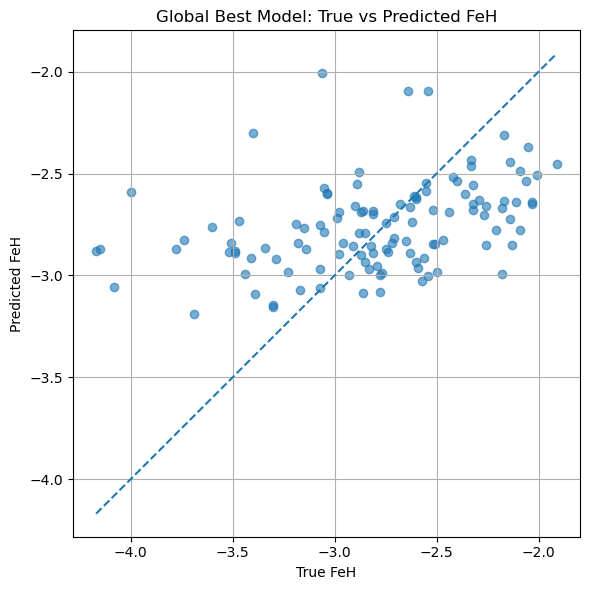

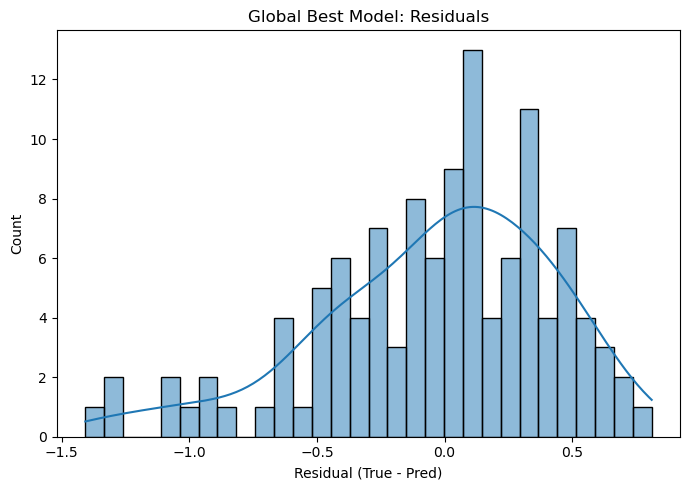

In [10]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


def brute_force_poly_feature_search(
    df,
    feature_cols,
    target_col="FeH",
    degrees=(1, 2),
    alphas=None,
    test_size=0.2,
    random_state=42,
    cv_folds=5,
    top_k_print=10,
):
    """
    Brute-force search over ALL combinations of which features get polynomial expansion.

    For each subset S of feature_cols:
      - S are "poly" features (optionally degree 1 or 2)
      - feature_cols \ S are "linear" (no polynomial expansion)
      - Pipeline: ColumnTransformer(poly + linear) -> StandardScaler -> Ridge
      - GridSearch over:
          - degree in `degrees` (if S is non-empty)
          - ridge alpha in `alphas`

    Returns:
      best_model, best_config, all_results
    """

    if alphas is None:
        alphas = np.logspace(-3, 3, 50)  # 1e-3 ... 1e3


    X = df[feature_cols]
    y = df[target_col].astype(float).values

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print("Feature columns:", feature_cols)
    print(f"Train size: {len(y_train)},  Val size: {len(y_val)}\n")

    # Helper: powerset of features
    def powerset(iterable):
        s = list(iterable)
        # includes empty set; we WANT that (baseline: no poly terms)
        return itertools.chain.from_iterable(
            itertools.combinations(s, r) for r in range(len(s) + 1)
        )

    results = []
    best_model = None
    best_val_rmse = np.inf
    best_config = None


    for poly_subset in powerset(feature_cols):
        poly_subset = list(poly_subset)
        linear_subset = [f for f in feature_cols if f not in poly_subset]

        print("===================================================")
        print(f"Trying poly features: {poly_subset if poly_subset else 'NONE'}")
        print(f"Linear-only features: {linear_subset}")


        transformers = []

        if poly_subset:
            transformers.append(
                ("poly", PolynomialFeatures(include_bias=False), poly_subset)
            )

        if linear_subset:
            transformers.append(("linear", "passthrough", linear_subset))

        if not transformers:
            print("No features in this configuration, skipping.")
            continue

        col_trans = ColumnTransformer(transformers=transformers)

        pipe = Pipeline(
            [
                ("features", col_trans),
                ("scaler", StandardScaler()),
                ("ridge", Ridge(max_iter=10000)),
            ]
        )

        # Parameter grid: if we have NO poly features, don't bother varying degree
        if poly_subset:
            param_grid = {
                "features__poly__degree": degrees,
                "ridge__alpha": alphas,
            }
        else:
            # degree is irrelevant; just tune alpha
            param_grid = {
                "ridge__alpha": alphas,
            }

        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="neg_mean_squared_error",
            cv=cv_folds,
        )

        # Fit on training set
        search.fit(X_train, y_train)

        # Best model for THIS subset
        local_best_model = search.best_estimator_
        local_best_params = search.best_params_
        y_pred_val = local_best_model.predict(X_val)

        val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        val_r2 = r2_score(y_val, y_pred_val)

        # Extract degree if we used poly
        if poly_subset:
            best_deg = local_best_params.get("features__poly__degree", 1)
        else:
            best_deg = 1  # effectively linear

        best_alpha = local_best_params.get("ridge__alpha")

        print(f"  -> Best degree: {best_deg}")
        print(f"  -> Best alpha:  {best_alpha:.4g}")
        print(f"  -> Val RMSE:    {val_rmse:.4f}")
        print(f"  -> Val R²:      {val_r2:.4f}\n")

        results.append(
            {
                "poly_features": poly_subset,
                "linear_features": linear_subset,
                "best_degree": best_deg,
                "best_alpha": best_alpha,
                "val_rmse": val_rmse,
                "val_r2": val_r2,
                "cv_results": search.cv_results_,
            }
        )

        # Track global best
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model = local_best_model
            best_config = results[-1]


    print("\n================= SUMMARY OF TOP CONFIGS =================")
    results_sorted = sorted(results, key=lambda r: r["val_rmse"])
    for i, r in enumerate(results_sorted[:top_k_print], start=1):
        print(f"\nRank {i}:")
        print(f"  Poly features:   {r['poly_features'] if r['poly_features'] else 'NONE'}")
        print(f"  Linear features: {r['linear_features']}")
        print(f"  Best degree:     {r['best_degree']}")
        print(f"  Best alpha:      {r['best_alpha']:.4g}")
        print(f"  Val RMSE:        {r['val_rmse']:.4f}")
        print(f"  Val R²:          {r['val_r2']:.4f}")


    if best_model is not None:
        print("\n================= GLOBAL BEST MODEL =================")
        print(
            f"Poly features:   {best_config['poly_features'] if best_config['poly_features'] else 'NONE'}"
        )
        print(f"Linear features: {best_config['linear_features']}")
        print(f"Best degree:     {best_config['best_degree']}")
        print(f"Best alpha:      {best_config['best_alpha']:.4g}")
        print(f"Val RMSE:        {best_config['val_rmse']:.4f}")
        print(f"Val R²:          {best_config['val_r2']:.4f}")

        # Recompute validation predictions to plot
        y_pred_best = best_model.predict(X_val)

        # True vs Predicted
        plt.figure(figsize=(6, 6))
        plt.scatter(y_val, y_pred_best, alpha=0.6)
        mn = min(y_val.min(), y_pred_best.min())
        mx = max(y_val.max(), y_pred_best.max())
        plt.plot([mn, mx], [mn, mx], "--")
        plt.xlabel("True FeH")
        plt.ylabel("Predicted FeH")
        plt.title("Global Best Model: True vs Predicted FeH")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Residuals
        residuals = y_val - y_pred_best
        plt.figure(figsize=(7, 5))
        sns.histplot(residuals, bins=30, kde=True)
        plt.xlabel("Residual (True - Pred)")
        plt.ylabel("Count")
        plt.title("Global Best Model: Residuals")
        plt.tight_layout()
        plt.show()

    return best_model, best_config, results_sorted



best_model, best_config, all_results = brute_force_poly_feature_search(
    selected_data,
    feature_cols=feature_cols,
    target_col=target_col,
    degrees=(1, 2),      # try linear and quadratic
    cv_folds=5,
)


# gradient boosting regression

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


def FeH_gradient_boosting_model(
    df,
    feature_cols,
    target_col='FeH',
    test_size=0.2,
    random_state=42,
    cv_folds=5
):
    """
    Trains GBM model to predict FeH.

    Returns:
        best_gb      : best GradientBoostingRegressor from GridSearchCV
        search       : fitted GridSearchCV object
        metrics      : dict of metrics, hyperparameters, and metadata
        val_output_df: DataFrame with validation features + true/pred target
    """


    train_idx, val_idx = train_test_split(
        df.index,
        test_size=test_size,
        random_state=random_state
    )

    X_train = df.loc[train_idx, feature_cols].values
    y_train = df.loc[train_idx, target_col].values.astype(float)

    X_val = df.loc[val_idx, feature_cols].values
    y_val = df.loc[val_idx, target_col].values.astype(float)

    print("Features used:", feature_cols)
    print(f"Train size: {len(y_train)},  Val size: {len(y_val)}")

    gb = GradientBoostingRegressor(random_state=random_state)

    param_grid = {
        "n_estimators": [200, 400, 800],
        "learning_rate": [0.003, 0.005, 0.01],
        "max_depth": [3, 4, 5],
        "subsample": [0.5, 0.6, 0.7],
        "min_samples_leaf": [5, 10],
    }

    search = GridSearchCV(
        gb,
        param_grid,
        scoring="neg_mean_squared_error",
        cv=cv_folds,
        n_jobs=-1
    )
    search.fit(X_train, y_train)

    best_gb = search.best_estimator_

    # ---------------------
    # 3. Validation metrics
    # ---------------------
    y_pred = best_gb.predict(X_val)

    best_cv_rmse = np.sqrt(-search.best_score_)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    val_r2 = r2_score(y_val, y_pred)

    print("\nBest GBM hyperparameters:")
    for k, v in search.best_params_.items():
        print(f"  {k}: {v}")

    print(f"\nBest CV RMSE (training folds): {best_cv_rmse:.4f}")
    print(f"\nValidation RMSE: {val_rmse:.4f}")
    print(f"Validation R^2:  {val_r2:.4f}")

    # ---------------------
    # 4. Plots
    # ---------------------

    # True vs Predicted
    plt.figure(figsize=(6, 6))
    plt.scatter(y_val, y_pred, alpha=0.6)
    mn = min(y_val.min(), y_pred.min())
    mx = max(y_val.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], "--")
    plt.xlabel(f"True {target_col}")
    plt.ylabel(f"Predicted {target_col}")
    plt.title(f"Gradient Boosting: True vs Predicted {target_col}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Residuals histogram
    residuals = y_val - y_pred
    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, bins=30, kde=True)
    plt.xlabel("Residual (True - Pred)")
    plt.ylabel("Count")
    plt.title("Gradient Boosting: Residuals (Validation)")
    plt.tight_layout()
    plt.show()

    # Feature importance
    importances = best_gb.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(7, 4))
    plt.bar(
        range(len(feature_cols)),
        importances[sorted_idx],
        tick_label=np.array(feature_cols)[sorted_idx]
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Feature Importance")
    plt.title("Gradient Boosting: Feature Importances")
    plt.tight_layout()
    plt.show()

    # ---------------------
    # 5. Metrics dict
    # ---------------------
    feature_importance_dict = {
        feature_cols[i]: float(importances[i])
        for i in range(len(feature_cols))
    }

    metrics = {
        "feature_cols": list(feature_cols),
        "target_col": target_col,
        "best_params": search.best_params_,
        "best_cv_rmse": float(best_cv_rmse),
        "val_rmse": float(val_rmse),
        "val_r2": float(val_r2),
        "feature_importances": feature_importance_dict,
        "train_size": int(len(train_idx)),
        "val_size": int(len(val_idx)),
        "random_state": random_state,
        "cv_folds": cv_folds,
    }

    # ---------------------
    # 6. Validation results dataframe
    # ---------------------
    val_output_df = df.loc[val_idx, feature_cols].copy()
    val_output_df[f"True_{target_col}"] = y_val
    val_output_df[f"Pred_{target_col}"] = y_pred

    return best_gb, search, metrics, val_output_df


### change the file paths

Features used: ['Teff', 'logg', 'bp_rp_dered', 'colorColorY', 'e_bv']
Train size: 469,  Val size: 118

Best GBM hyperparameters:
  learning_rate: 0.01
  max_depth: 5
  min_samples_leaf: 10
  n_estimators: 400
  subsample: 0.7

Best CV RMSE (training folds): 0.4796

Validation RMSE: 0.4101
Validation R^2:  0.3179


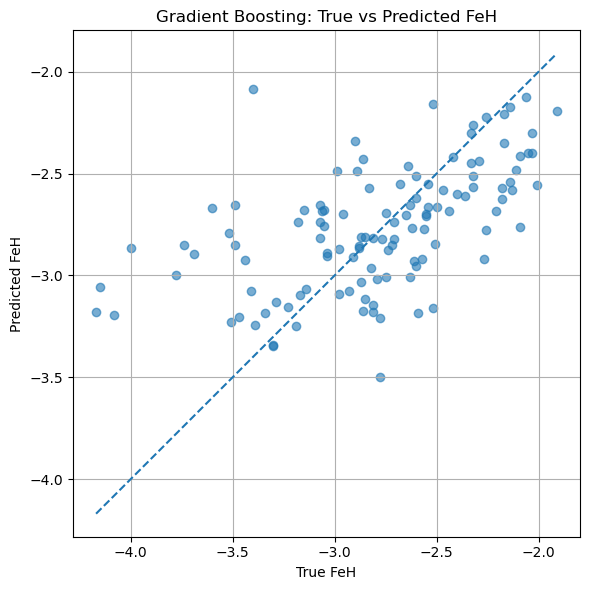

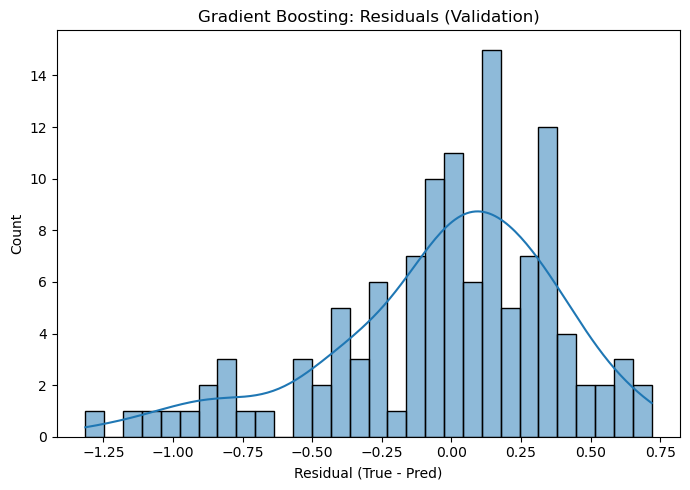

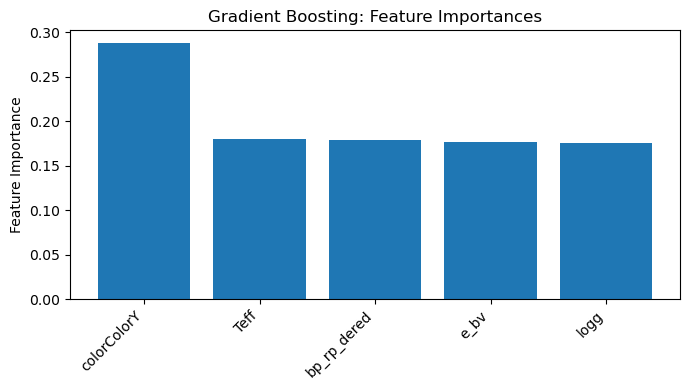

In [7]:
import json

best_gb, search, metrics, val_output_df = FeH_gradient_boosting_model(
    selected_data,
    feature_cols=feature_cols,
    target_col='FeH',
    test_size=0.2,
    random_state=42,
    cv_folds=5
)


import joblib
joblib.dump(best_gb, r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_model_COLOR.p")
joblib.dump(scaler, r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_scaler_COLOR.p")
json.dump(feature_cols, open(r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_features_COLOR.json", "w"))

# Save metrics to JSON
with open(r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_results_COLOR.json", "w") as f:
    json.dump(metrics, f, indent=4)

# Save validation predictions + features to CSV
val_output_df.to_csv(r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm_scaled_val_predictions_COLOR.csv", index=False)


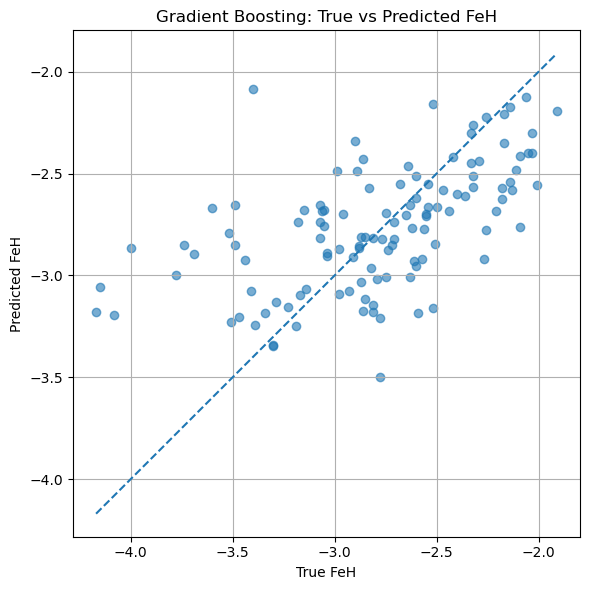

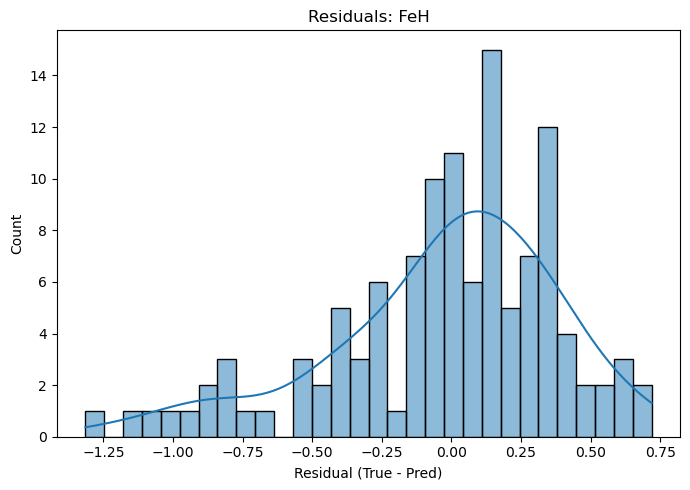

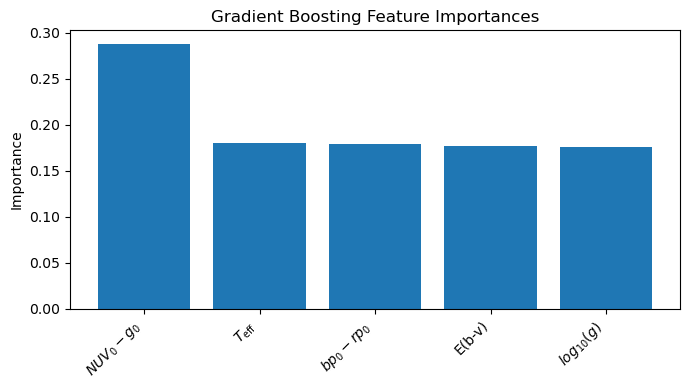

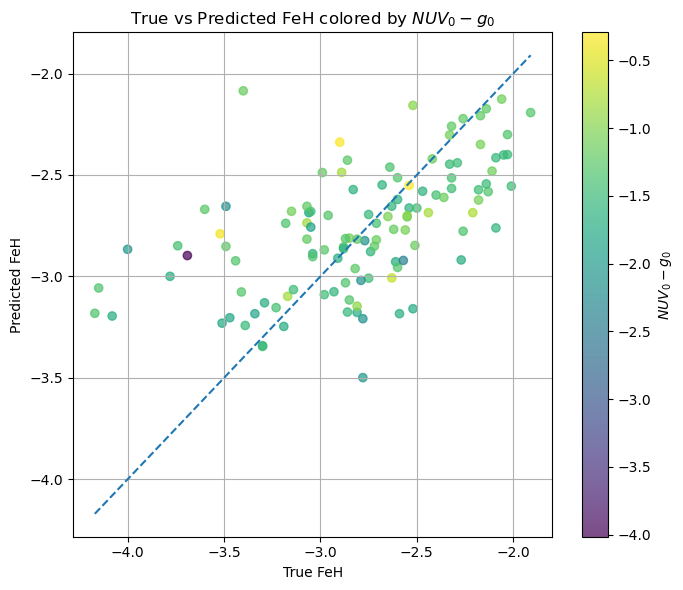

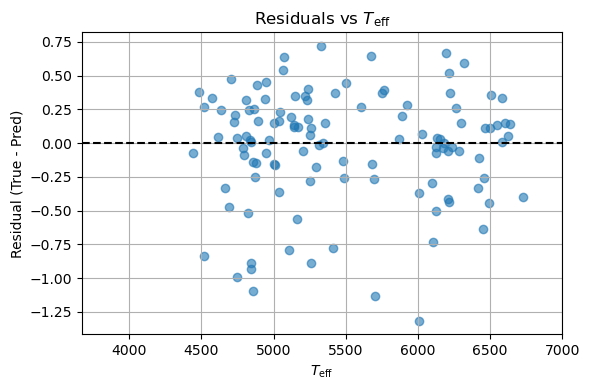

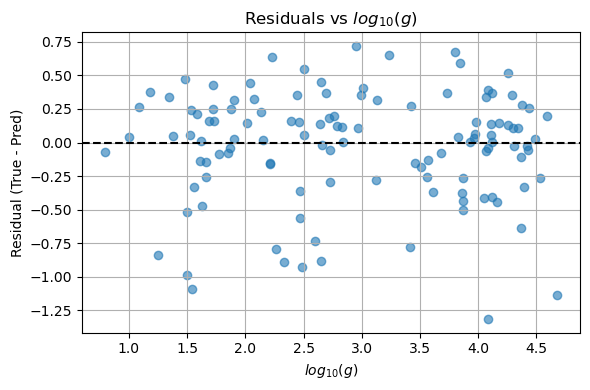

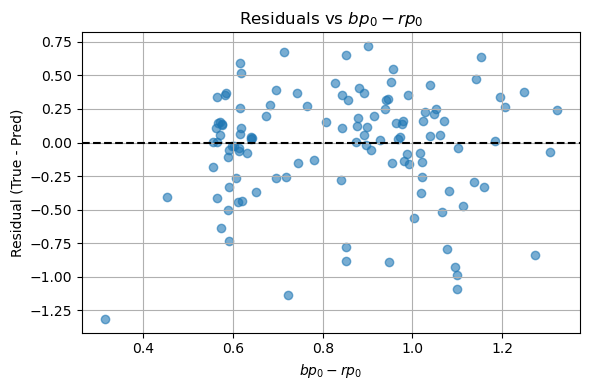

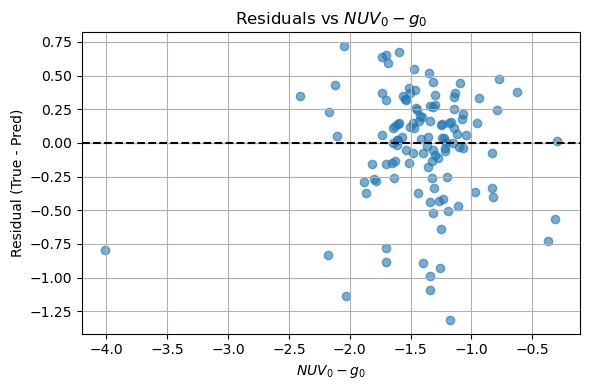

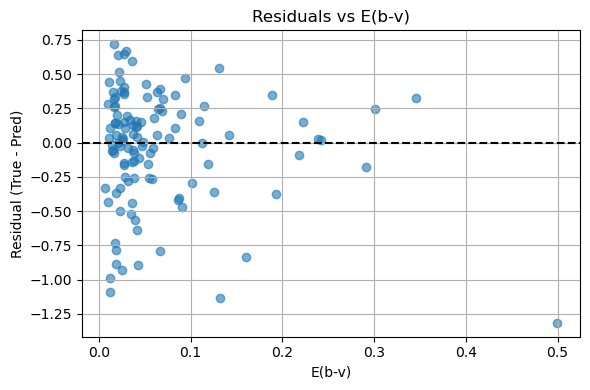

In [33]:
import json
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

FEATURE_LABELS = {
    "colorColorY": r"$NUV_{\mathrm{0}}-g_{\mathrm{0}}$",
    "bp_rp_dered": r"$bp_{\mathrm{0}}-rp_{\mathrm{0}}$",
    "e_bv": "E(b-v)",
    "logg" : r"$log_{\mathrm{10}}(g)$",
    "Teff": r"$T_{\mathrm{eff}}$" 
    # Add any other magnitude features you want labeled:
    # "nuv_mag": "NUV₀",
    # "g_mag": "g₀",
    # "bp_mag": "bp₀",
    # "rp_mag": "rp₀",

}


def pretty_label(name):
    """Return human-readable label if dictionary has it, else return name."""
    return FEATURE_LABELS.get(name, name)


def load_gbm_results(json_path, csv_path):
    with open(json_path, "r") as f:
        metrics = json.load(f)
    val_df = pd.read_csv(csv_path)
    return metrics, val_df


def plot_true_vs_pred(val_df, metrics):
    target_col = metrics["target_col"]
    true_col = f"True_{target_col}"
    pred_col = f"Pred_{target_col}"

    y_true = val_df[true_col].values
    y_pred = val_df[pred_col].values

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], "--")

    plt.xlabel(f"True {pretty_label(target_col)}")
    plt.ylabel(f"Predicted {pretty_label(target_col)}")
    plt.title(f"Gradient Boosting: True vs Predicted {pretty_label(target_col)}")

    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_residuals(val_df, metrics):
    target_col = metrics["target_col"]
    true_col = f"True_{target_col}"
    pred_col = f"Pred_{target_col}"

    residuals = val_df[true_col] - val_df[pred_col]

    plt.figure(figsize=(7, 5))
    sns.histplot(residuals, bins=30, kde=True)

    plt.xlabel("Residual (True - Pred)")
    plt.ylabel("Count")
    plt.title(f"Residuals: {pretty_label(target_col)}")

    plt.tight_layout()
    plt.show()


def plot_feature_importances(metrics):
    fi = metrics["feature_importances"]
    features = np.array([pretty_label(k) for k in fi.keys()])
    importances = np.array(list(fi.values()))

    sorted_idx = np.argsort(importances)[::-1]

    plt.figure(figsize=(7, 4))
    plt.bar(
        range(len(features)),
        importances[sorted_idx],
        tick_label=features[sorted_idx]
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title("Gradient Boosting Feature Importances")
    plt.tight_layout()
    plt.show()


def plot_true_vs_pred_colored(val_df, metrics, color_by):
    target_col = metrics["target_col"]
    true_col = f"True_{target_col}"
    pred_col = f"Pred_{target_col}"

    label = pretty_label(color_by)

    y_true = val_df[true_col].values
    y_pred = val_df[pred_col].values
    cvals  = val_df[color_by].values

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(y_true, y_pred, c=cvals, alpha=0.7)

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], "--")

    plt.xlabel(f"True {pretty_label(target_col)}")
    plt.ylabel(f"Predicted {pretty_label(target_col)}")
    plt.title(f"True vs Predicted {pretty_label(target_col)} colored by {label}")
    cb = plt.colorbar(sc)
    cb.set_label(label)

    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_residuals_vs_features(val_df, metrics, feature_cols=None):
    target_col = metrics["target_col"]
    true_col = f"True_{target_col}"
    pred_col = f"Pred_{target_col}"

    residuals = val_df[true_col] - val_df[pred_col]

    if feature_cols is None:
        feature_cols = [
            f for f in metrics["feature_importances"].keys() if f in val_df.columns
        ]

    for feat in feature_cols:
        label = pretty_label(feat)

        plt.figure(figsize=(6, 4))
        plt.scatter(val_df[feat].values, residuals.values, alpha=0.6)
        plt.axhline(0.0, color="k", linestyle="--")

        # ----- NEW: Teff axis limit -----
        if feat == "Teff":
            plt.xlim(None, 7000)  # upper limit at 7000 K

        plt.xlabel(label)
        plt.ylabel("Residual (True - Pred)")
        plt.title(f"Residuals vs {label}")

        plt.grid(True)
        plt.tight_layout()
        plt.show()



metrics, val_df = load_gbm_results(
    r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_results_COLOR.json",
    r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm_scaled_val_predictions_COLOR.csv"
)

plot_true_vs_pred(val_df, metrics)
plot_residuals(val_df, metrics)
plot_feature_importances(metrics)
plot_true_vs_pred_colored(val_df, metrics, color_by="colorColorY")
plot_residuals_vs_features(val_df, metrics)


In [11]:
# apply model to galex dataset

In [29]:
# Optional: mapping from internal names to nicer labels
import json
import json

FEATURE_LABELS = {
    "colorColorY": r"$NUV_{\mathrm{0}}-g_{\mathrm{0}}$",
    "bp_rp_dered": r"$bp_{\mathrm{0}}-rp_{\mathrm{0}}$",
    "e_bv": "E(b-v)",
    "logg" : r"$log_{\mathrm{10}}g$",
    "Teff": r"$T_{\mathrm{eff}}$" 
    # Add any other magnitude features you want labeled:
    # "nuv_mag": "NUV₀",
    # "g_mag": "g₀",
    # "bp_mag": "bp₀",
    # "rp_mag": "rp₀",

}


def pretty_label(name):
    return FEATURE_LABELS.get(name, name)
EMP_THRESHOLD = -3.0  # [Fe/H] < -3 => EMP
def load_gbm_results(json_path, csv_path):

    with open(json_path, "r") as f:
        metrics = json.load(f)
    val_df = pd.read_csv(csv_path)
    return metrics, val_df


EMP_THRESHOLD = -3.0  # FeH < -3 => EMP

EMP_THRESHOLD = -3.0  # FeH < -3 => EMP

def apply_model_to_new_data(model_path,
                            new_csv_path,
                            metrics,
                            feature_cols=None):


    target_col = metrics["target_col"]


    model = joblib.load(model_path)


    if feature_cols is None:
        if "feature_importances" in metrics:
            feature_cols = list(metrics["feature_importances"].keys())
        else:
            raise ValueError(
                "feature_cols must be provided if 'feature_importances' not in metrics."
            )

    new_df = pd.read_csv(new_csv_path)

    missing = [f for f in feature_cols if f not in new_df.columns]
    if missing:
        raise ValueError(f"Missing feature columns in new data: {missing}")

    X_feats = new_df[feature_cols].copy()
    X_feats = X_feats.replace([np.inf, -np.inf], np.nan)

    mask_good = ~X_feats.isna().any(axis=1)
    n_bad = (~mask_good).sum()
    print(f"Dropping {n_bad} rows with NaNs/infs in features for prediction.")

    X_new = X_feats.loc[mask_good].values


    pred_FeH = model.predict(X_new)
    pred_col = f"Pred_{target_col}"

    new_df[pred_col] = np.nan
    new_df.loc[mask_good, pred_col] = pred_FeH

    new_df["EMP_flag"] = False
    new_df.loc[mask_good, "EMP_flag"] = new_df.loc[mask_good, pred_col] < EMP_THRESHOLD

    x_col = "bp_rp_dered"
    y_col = "colorColorY"

    if x_col not in new_df.columns or y_col not in new_df.columns:
        raise ValueError(f"Color-color columns {x_col} or {y_col} not found in new_df.")

    # Only plot rows with valid predictions (mask_good)
    cc_mask = mask_good & new_df[x_col].notna() & new_df[y_col].notna()
    x = new_df.loc[cc_mask, x_col].values
    y = new_df.loc[cc_mask, y_col].values
    is_emp = new_df.loc[cc_mask, "EMP_flag"].values

    plt.figure(figsize=(7, 5))

    # Non-EMP
    plt.scatter(x[~is_emp], y[~is_emp], alpha=0.5, label="Non-EMP")

    # EMP
    plt.scatter(x[is_emp], y[is_emp], alpha=0.9, marker="x", label="EMP (Pred < -3)")

    plt.xlabel(pretty_label(x_col))
    plt.ylabel(pretty_label(y_col))
    plt.title("Color–color diagram with EMP candidates (predicted)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return new_df


Dropping 1 rows with NaNs/infs in features for prediction.


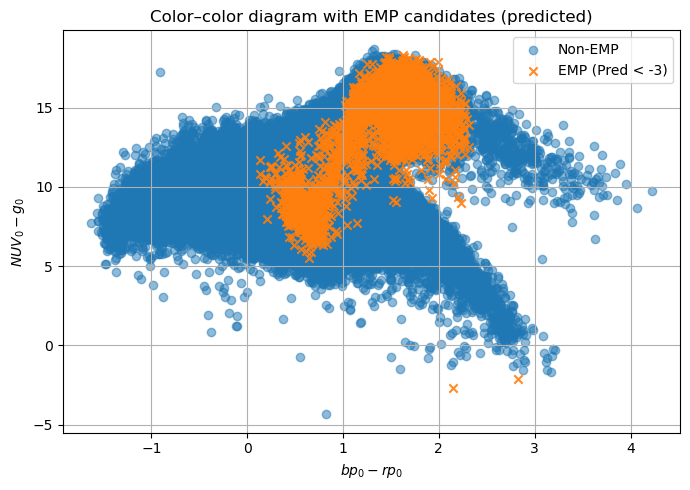

In [30]:
# 1. Reload validation results (unchanged)
metrics, val_df = load_gbm_results(
    r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_results_COLOR.json",
    r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm_scaled_val_predictions_COLOR.csv"
)

# 3. Apply model to the Gaia+GALEX catalog (no ground truth FeH)
MODEL_PATH = r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_model_COLOR.p"
NEW_DATA_PATH = r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\ml_gaiaXGALEXDat.csv"

new_df_with_preds = apply_model_to_new_data(
    model_path=MODEL_PATH,
    new_csv_path=NEW_DATA_PATH,
    metrics=metrics,
    feature_cols=None  # infer from metrics["feature_importances"]
)


In [34]:
import json
path = r"C:\Users\xswu0\Documents\Observational Astrophysics class\Machine_learning_Project\Data\Results\FeH_gbm__scaled_results_COLOR.json"
with open(path) as f:
    m = json.load(f)
print(m.get("best_params_", m))


{'feature_cols': ['Teff', 'logg', 'bp_rp_dered', 'colorColorY', 'e_bv'], 'target_col': 'FeH', 'best_params': {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 400, 'subsample': 0.7}, 'best_cv_rmse': 0.47956400904873725, 'val_rmse': 0.4101122439281749, 'val_r2': 0.3179220028924721, 'feature_importances': {'Teff': 0.17996808201157566, 'logg': 0.17592093881318563, 'bp_rp_dered': 0.1790059212023096, 'colorColorY': 0.28796395451296236, 'e_bv': 0.1771411034599668}, 'train_size': 469, 'val_size': 118, 'random_state': 42, 'cv_folds': 5}
